In [1]:
import subprocess
import sys
import re
import os
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib as mpl
import seaborn as sns
import seaborn.objects as so
import warnings
warnings.filterwarnings("ignore")
import multiprocessing as mp
import itertools

from astropy import units as u
import numpy as np
from astropy.constants import G, sigma_sb, k_B

from scipy.interpolate import PchipInterpolator
from process_evotracks import evolution_track as track

### Planet/Impact param set up

$\Delta S = \frac{\Delta Q}{T}$, where $T$ is approximated as $T_{eq}$ and core heating is ignored

- Core cooling might prolong the inflation?

$E_{imp} = \eta M_{imp} \frac{GM_p}{R_c}$

$S-S_0 = \frac{E_{imp}}{T_{eq}}$

### Code set up and compile

In [2]:
def __pl_density_cgs(radius, mass, rad_err = None, mass_err = None):
    """
    Calculate the bulk density of a planet in cgs units (g/cm³) with error propagation.

    Parameters
    ----------
    radius : float or `~astropy.units.Quantity`
        Planetary radius. If a float is provided, it is assumed to be in Earth radii.
        If a `Quantity` is provided, it must be compatible with length units.

    mass : float or `~astropy.units.Quantity`
        Planetary mass. If a float is provided, it is assumed to be in Earth masses.
        If a `Quantity` is provided, it must be compatible with mass units.

    rad_err : float, array-like, `~astropy.units.Quantity`, or None, optional
        Uncertainty in planetary radius. If a float is provided, it is assumed to be
        in the same units as radius. If array-like of length 2, treated as
        asymmetric errors [lower, upper] and averaged for symmetric approximation.
        If None, no error propagation is performed.

    mass_err : float, array-like, `~astropy.units.Quantity`, or None, optional
        Uncertainty in planetary mass. If a float is provided, it is assumed to be
        in the same units as mass. If array-like of length 2, treated as
        asymmetric errors [lower, upper] and averaged for symmetric approximation.
        If None, no error propagation is performed.

    Returns
    -------
    density : `~astropy.units.Quantity`
        Planetary bulk density in grams per cubic centimeter (g/cm³).

    density_err : `~astropy.units.Quantity`, array, or None
        Uncertainty in planetary bulk density in g/cm³. Returns None if neither
        rad_err nor mass_err is provided. If input errors are asymmetric (length-2 arrays),
        returns asymmetric errors as array [lower_error, upper_error]. Otherwise returns
        symmetric error as scalar Quantity.

    Notes
    -----
    - If both inputs are floats, the function assumes they are in Earth units.
    - Automatically converts units to CGS (centimeters and grams) before computing.
    - Volume is computed assuming a spherical planet.
    - Error propagation uses standard uncertainty propagation formulas for
        density = mass / ((4/3) * π * radius³). For asymmetric input errors,
        the method properly propagates them to asymmetric density errors by
        considering the sign of partial derivatives.
    """
    #----Unit handling-----#
    # Handle radius units
    if not isinstance(radius, u.Quantity):
        radius = radius * u.R_earth  # assume in Earth radii

    # Handle mass units
    if not isinstance(mass, u.Quantity):
        mass = mass * u.M_earth  # assume in Earth masses

    # Handle radius error units
    if rad_err is not None:
        if not isinstance(rad_err, u.Quantity):
            # Assume same units as radius before conversion
            if not isinstance(radius, u.Quantity):
                rad_err = rad_err * u.R_earth
            else:
                rad_err = rad_err * radius.unit

    # Handle mass error units
    if mass_err is not None:
        if not isinstance(mass_err, u.Quantity):
            # Assume same units as mass before conversion
            if not isinstance(mass, u.Quantity):
                mass_err = mass_err * u.M_earth
            else:
                mass_err = mass_err * mass.unit

    # Convert to cgs
    radius_cgs = radius.to(u.cm)
    mass_cgs = mass.to(u.g)
    mass_err_cgs = None
    rad_err_cgs = None
    if rad_err is not None:
        rad_err_cgs = rad_err.to(u.cm)
    if mass_err is not None:
        mass_err_cgs = mass_err.to(u.g)

    # Calculate density
    V = (4 / 3) * np.pi * radius_cgs ** 3
    density = mass_cgs / V

    # Calculate error if requested
    density_err = None
    if rad_err is not None or mass_err is not None:
        # Partial derivatives for error propagation
        # ρ = M / ((4/3)πR³)
        # ∂ρ/∂M = 1 / ((4/3)πR³) = ρ/M
        # ∂ρ/∂R = -3M / ((4/3)πR⁴) = -3ρ/R

        # Check if we have asymmetric errors
        mass_is_asymmetric = mass_err is not None and hasattr(mass_err_cgs, '__len__') and len(mass_err_cgs) == 2
        rad_is_asymmetric = rad_err is not None and hasattr(rad_err_cgs, '__len__') and len(rad_err_cgs) == 2

        if mass_is_asymmetric or rad_is_asymmetric:
            # Handle asymmetric error propagation
            dρ_dM = density / mass_cgs if mass_err is not None else 0
            dρ_dR = -3 * density / radius_cgs if rad_err is not None else 0

            # Calculate lower and upper bounds
            err_lower_terms = []
            err_upper_terms = []

            if mass_err is not None:
                if mass_is_asymmetric:
                    # For mass: positive derivative, so lower mass error -> lower density error
                    err_lower_terms.append((dρ_dM * mass_err_cgs[0]) ** 2)
                    err_upper_terms.append((dρ_dM * mass_err_cgs[1]) ** 2)
                else:
                    # Symmetric mass error
                    mass_term = (dρ_dM * mass_err_cgs) ** 2
                    err_lower_terms.append(mass_term)
                    err_upper_terms.append(mass_term)

            if rad_err is not None:
                if rad_is_asymmetric:
                    # For radius: negative derivative, so lower radius error -> upper density error
                    err_lower_terms.append((dρ_dR * rad_err_cgs[1]) ** 2)  # Note: switched indices
                    err_upper_terms.append((dρ_dR * rad_err_cgs[0]) ** 2)  # Note: switched indices
                else:
                    # Symmetric radius error
                    rad_term = (dρ_dR * rad_err_cgs) ** 2
                    err_lower_terms.append(rad_term)
                    err_upper_terms.append(rad_term)

            density_err_lower = np.sqrt(sum(err_lower_terms))
            density_err_upper = np.sqrt(sum(err_upper_terms))

            # Return as array [lower, upper] with proper units
            density_err = np.array([density_err_lower.value, density_err_upper.value]) * density.unit

        else:
            # Handle symmetric error propagation
            err_terms = []

            if mass_err is not None:
                dρ_dM = density / mass_cgs
                err_terms.append((dρ_dM * mass_err_cgs) ** 2)

            if rad_err is not None:
                dρ_dR = -3 * density / radius_cgs
                err_terms.append((dρ_dR * rad_err_cgs) ** 2)

            if err_terms:
                density_err = np.sqrt(sum(err_terms))

    if density_err is None:
        return density
    else:
        return density, density_err
    

In [3]:
controls = {0.05:"controls/evo-control-f005.dat",0.1:"controls/evo-control-f01.dat",0.2:"controls/evo-control-f02.dat",0.3:"controls/evo-control-f03.dat",}
prefix_005 = "./PlanetSolver -cn 1 0.0162495 -en 2 0.6412495 -a 9.50 30 0.05 -s 1 1 1 0.3 -m 8.0 -evolve 1"
prefix_01 = "./PlanetSolver -cn 1 0.2925 -en 2 0.607495 -a 8.9 30 0.1 -s 1 1 1 0.3 -m 8.0 -evolve 1"
prefix_02 = "./PlanetSolver -cn 1 0.2599 -en 2 0.53995 -a 8.38 30 0.2 -s 1 1 1 0.3 -m 8.0 -evolve 1"
prefix_03 = "./PlanetSolver -cn 1 0.227495 -en 2 0.47249  -a 7.96 30 0.3 -s 1 1 1 0.3 -m 8.0 -evolve 1"
prefix_cmds = {0.05:prefix_005, 0.1:prefix_01, 0.2:prefix_02, 0.3:prefix_03}
runswitch = False

In [4]:
if False:
    result = subprocess.run(
    "make clean", 
    shell=True, 
    capture_output=True, 
    text=True,
    timeout=300
    )
    if result.returncode != 0:
        raise OSError("OS could not handle make clean")
    print("Cleaned")

    result = subprocess.run(
    "make", 
    shell=True, 
    capture_output=True, 
    text=True,
    timeout=300
    )
    if result.returncode != 0:
        print(result.stdout)
        raise OSError(f"Could not make:{result.stderr}")
    print("Made")




In [5]:
#multiprocessing

def run_sims(impact_mass_fraction, f_env, impact_time = 1000):
    
    assert impact_time % 1 == 0, "Don't input decimal impact times"

    #ASSUMPTIONS TO BE CHECKED AFTER TESTING
    M_p = 8 * u.Mearth
    R_p = 10 * u.Rearth
    M_core = (1-f_env) * M_p
    R_c = R_p * (M_core/M_p) ** 4  
    eta = 0.5 # Realistic ish value


    M_imp = impact_mass_fraction * M_core
    E_imp = eta * M_imp * (G * M_p)/R_c
    pcmd = prefix_cmds[f_env]
    
    try:
        magstr = str(impact_mass_fraction).replace(".","-")
        evolvefilename = f"AMF_fig_data/{f_env:3f}-{magstr}.dat"
        runcmd = (pcmd +
                   f" -impact {str(E_imp.si.value).replace("+", "")} {int(impact_time)} -struct AMF_fig_data/dni/{magstr}-{f_env:.3f}.dat -wr {evolvefilename}")
        print(runcmd)
        result = subprocess.run(
        runcmd, 
        shell=True, 
        capture_output=True, 
        text=True,
        timeout=600
        )
        if result.returncode != 0:
            print(result.stdout)
            raise OSError("Runtime error")
        print("Executed with exit code 0")
        print(result.stdout)

        with open(evolvefilename, "r") as file:
            lines = sum(1 for line in file)
            if lines < 200: 
                result = subprocess.run(
                runcmd, 
                shell=True, 
                capture_output=True, 
                text=True,
                timeout=600
                )
                if result.returncode != 0:
                    print(result.stdout)
                    raise OSError("Runtime error")
                print("Executed with exit code 0")
                print(result.stdout)

        return result
    except subprocess.TimeoutExpired as timeout:
        print(timeout.with_traceback(None))
        return None

impact_massfracs = [0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008, 0.009, 0.01]
amfs = list(prefix_cmds.keys())
#amfs = [0.05]
param_combos = itertools.product(impact_massfracs, amfs) #cartesian product operator
impact_time = 1000 #Myr



if runswitch:
    with mp.Pool(processes=mp.cpu_count()-1) as pool:
        all_results = pool.starmap(run_sims, param_combos)



In [6]:
if runswitch:
    for result in all_results:
        if result is not None:
            print(result.stdout)
            print(result.stderr)
        else:
            print("None")

In [7]:
efile = "1GYR/impact-fenv005-evo-0-004.dat"
input_col_names = ['Age', 'Atmospheric Entropy', 'Radius', 'Mass', 'delta_M', 'AMF', 'T_eff']
with open(efile, 'r') as file:
    lines = file.readlines()
data_start_idx = None
header_lines = []
    
for i, line in enumerate(lines):
    line = line.strip()
    # Look for the column headers
    if 'Age (Myr)' in line and 'Entropy' in line and 'Radius' in line:
        data_start_idx = i+1 #skips heading column
        break
    else:
        header_lines.append(line)

df = pd.read_table(efile, skiprows=data_start_idx, names=input_col_names, sep=" ")
df

,Age,Atmospheric Entropy,Radius,Mass,delta_M,AMF,T_eff
0,0.000000,9.1000,9.98995,8.00048,0.000000e+00,0.049950,0.000
1,0.006360,9.0900,6.35221,8.00047,5.848290e-06,0.049949,611.566
2,0.022498,9.0800,6.29573,8.00047,4.033250e-06,0.049949,607.233
3,0.039353,9.0700,6.23995,8.00046,4.106380e-06,0.049948,602.912
4,0.056955,9.0600,6.18831,8.00046,4.180900e-06,0.049948,598.626
...,...,...,...,...,...,...,...
131,1009.930000,10.2244,15.69610,7.95782,2.187770e-06,0.044858,254.442
132,1009.930000,10.2144,15.69610,7.95782,2.501530e-09,0.044858,2367.960
133,1009.930000,10.2044,15.69610,7.95782,2.581250e-09,0.044858,2347.700
134,1009.930000,10.1944,15.69610,7.95782,2.662680e-09,0.044858,2327.800


In [8]:
def get_allfiles(directory='sim_results', massfrac=0.3):
    """
    Create a dictionary mapping float values (0.Y) to filenames.
    
    Args:
        directory: Path to the directory containing the files (default: current directory)
    
    Returns:
        dict[float, str]: Dictionary mapping float values to filenames
    """
    result = {}
    massfrac_str = str(massfrac).replace(".", "")
    # Pattern to match impact-fenvXX-evo-0-Y.dat
    pattern = rf'impact-fenv{massfrac_str}-evo-0-(\d+)\.dat'
    
    # Iterate through files in directory
    for filename in os.listdir(directory):
        match = re.match(pattern, filename)
        if match:
            # Extract Y value
            y_value = match.group(1)
            # Create float as 0.Y
            key = float(f"0.{y_value}")
            result[key] = filename
    
    return result

get_allfiles(massfrac=0.2)

{0.001: 'impact-fenv02-evo-0-001.dat',
 0.0013: 'impact-fenv02-evo-0-0013.dat',
 0.002: 'impact-fenv02-evo-0-0020.dat',
 0.003: 'impact-fenv02-evo-0-003.dat',
 0.0016: 'impact-fenv02-evo-0-0016.dat',
 0.0026: 'impact-fenv02-evo-0-0026.dat',
 0.0023: 'impact-fenv02-evo-0-0023.dat',
 0.0033: 'impact-fenv02-evo-0-0033.dat',
 0.0036: 'impact-fenv02-evo-0-0036.dat',
 0.004: 'impact-fenv02-evo-0-004.dat',
 0.0043: 'impact-fenv02-evo-0-0043.dat',
 0.0046: 'impact-fenv02-evo-0-0046.dat',
 0.005: 'impact-fenv02-evo-0-005.dat',
 0.0053: 'impact-fenv02-evo-0-0053.dat',
 0.0056: 'impact-fenv02-evo-0-0056.dat',
 0.006: 'impact-fenv02-evo-0-006.dat',
 0.0063: 'impact-fenv02-evo-0-0063.dat',
 0.0066: 'impact-fenv02-evo-0-0066.dat',
 0.007: 'impact-fenv02-evo-0-007.dat',
 0.0073: 'impact-fenv02-evo-0-0073.dat',
 0.0076: 'impact-fenv02-evo-0-0076.dat',
 0.008: 'impact-fenv02-evo-0-008.dat',
 0.0083: 'impact-fenv02-evo-0-0083.dat',
 0.0086: 'impact-fenv02-evo-0-0086.dat',
 0.009: 'impact-fenv02-evo-0-00

In [9]:
def check_file(path):
    with open(f"{path}", "r") as file:
        lines = sum(1 for line in file)
        if lines < 200:
            return False
    df = track.load_track(f"{path}")
    if max(df["Age"]) < 6000: 
        return False
    
    return True


In [10]:
list(get_allfiles(massfrac=0.1).keys())

[0.0012,
 0.001,
 0.0015,
 0.0017,
 0.0025,
 0.0022,
 0.002,
 0.0027,
 0.003,
 0.0032,
 0.0035,
 0.0037,
 0.004,
 0.0042,
 0.0045,
 0.0047,
 0.005,
 0.0052,
 0.0055,
 0.0057,
 0.006,
 0.0062,
 0.0065,
 0.0067,
 0.007]

### View the modeled evolution

In [11]:
input_col_names = ['Age', 'Atmospheric Entropy', 'Radius', 'Mass', 'delta_M', 'AMF', 'T_eff']
evodfs_005 = {}
evodfs_01 = {}
evodfs_02 = {}
evodfs_03 = {}
#impact_massfracs = [0.001, 0.002, 0.003, 0.004, 0.005, 0.0055, 0.006, 0.0061, 0.0066, 0.007, 0.0072, 0.0077, 0.008, 0.0083, 0.0088, 0.009, 0.0094, 0.01]
impact_massfracs = []
amfs = list(prefix_cmds.keys())
amfs = [0.1, 0.2, 0.3]
#param_combos = itertools.product(impact_massfracs, amfs)

removed = []
for f_env in amfs:
    impact_massfracs = list(get_allfiles(massfrac=f_env).keys())
    for impactfrac in impact_massfracs:
        
        print(f"({f_env},{impactfrac})")
        factor_filename = str(impactfrac).replace(".","-")
        efile = f"sim_results/impact-fenv{str(f_env).replace(".","")}-evo-{factor_filename}.dat"
        efile = f"sim_results/{get_allfiles(massfrac=f_env)[impactfrac]}"
        if check_file(efile):
            try:
                evodf = track.load_track(efile)
            except Exception as e:
                continue
            
            
            match f_env:
                case 0.05:
                    evodfs_005[impactfrac] = evodf
                    
                case 0.1:
                    evodfs_01[impactfrac] = evodf
                case 0.2:
                    evodfs_02[impactfrac] = evodf
                case 0.3:
                    evodfs_03[impactfrac] = evodf
                case _:
                    print("unrecognized f_env")
        else:
            removed.append(efile)
            continue

dfcontrols = {}
for fenv, path in controls.items():
    dfcontrols[fenv] = track.load_track(path)

evodfdicts = {0.05:evodfs_005, 0.1:evodfs_01, 0.2:evodfs_02, 0.3:evodfs_03}

(0.1,0.0012)
(0.1,0.001)
(0.1,0.0015)
(0.1,0.0017)
(0.1,0.0025)
(0.1,0.0022)
(0.1,0.002)
(0.1,0.0027)
(0.1,0.003)
(0.1,0.0032)
(0.1,0.0035)
(0.1,0.0037)
(0.1,0.004)
(0.1,0.0042)
(0.1,0.0045)
(0.1,0.0047)
(0.1,0.005)
(0.1,0.0052)
(0.1,0.0055)
(0.1,0.0057)
(0.1,0.006)
(0.1,0.0062)
(0.1,0.0065)
(0.1,0.0067)
(0.1,0.007)
(0.2,0.001)
(0.2,0.0013)
(0.2,0.002)
(0.2,0.003)
(0.2,0.0016)
(0.2,0.0026)
(0.2,0.0023)
(0.2,0.0033)
(0.2,0.0036)
(0.2,0.004)
(0.2,0.0043)
(0.2,0.0046)
(0.2,0.005)
(0.2,0.0053)
(0.2,0.0056)
(0.2,0.006)
(0.2,0.0063)
(0.2,0.0066)
(0.2,0.007)
(0.2,0.0073)
(0.2,0.0076)
(0.2,0.008)
(0.2,0.0083)
(0.2,0.0086)
(0.2,0.009)
(0.2,0.0012)
(0.2,0.0021)
(0.2,0.0014)
(0.2,0.0018)
(0.2,0.0025)
(0.2,0.0027)
(0.2,0.0001)
(0.2,0.0007)
(0.2,0.0009)
(0.2,0.0003)
(0.2,0.0011)
(0.2,0.0005)
(0.2,0.0022)
(0.2,0.0008)
(0.2,0.0006)
(0.2,0.0002)
(0.2,0.0004)
(0.2,0.0015)
(0.3,0.001)
(0.3,0.0026)
(0.3,0.0029)
(0.3,0.0013)
(0.3,0.0023)
(0.3,0.0019)
(0.3,0.0016)
(0.3,0.0032)
(0.3,0.0036)
(0.3,0.0039)
(0.

In [12]:
evodfdicts[0.2].keys()

dict_keys([0.001, 0.0013, 0.002, 0.003, 0.0016, 0.0026, 0.0023, 0.0033, 0.0036, 0.004, 0.0043, 0.0046, 0.005, 0.0053, 0.0056, 0.006, 0.0063, 0.0066, 0.007, 0.0073, 0.0076, 0.008, 0.0083, 0.0086, 0.009, 0.0012, 0.0021, 0.0014, 0.0018, 0.0025, 0.0027, 0.0001, 0.0007, 0.0009, 0.0003, 0.0011, 0.0005, 0.0022, 0.0008, 0.0006, 0.0002, 0.0004, 0.0015])

In [13]:
impact_massfracs_original = [0.001, 0.002, 0.003, 0.004, 0.005, 0.0055, 0.006, 0.0061, 0.0066, 0.007, 0.0072, 0.0077, 0.008, 0.0083, 0.0088, 0.009, 0.0094, 0.01]
amfs = [0.3]
param_combos = itertools.product(impact_massfracs_original, amfs)
for tup in param_combos:
    impactfrac = tup[0]
    f_env = tup[1]
    factor_filename = str(impactfrac).replace(".","-")
    efile = f"1GYR/impact-fenv{str(f_env).replace(".","")}-evo-{factor_filename}.dat"
    try:
        evodf = track.load_track(efile)
    except Exception as e:
        continue
        
    print(f"({tup[0]},{tup[1]})")
    match tup[1]:
        case 0.05:
            evodfs_005[impactfrac] = evodf
            
        case 0.1:
            evodfs_01[impactfrac] = evodf
        case 0.2:
            evodfs_02[impactfrac] = evodf
        case 0.3:
            evodfs_03[impactfrac] = evodf
        case _:
            print("unrecognized f_env")

for fenv, path in controls.items():
    dfcontrols[fenv] = track.load_track(path)

(0.001,0.3)
(0.002,0.3)
(0.003,0.3)
(0.004,0.3)
(0.005,0.3)
(0.006,0.3)
(0.007,0.3)
(0.008,0.3)
(0.009,0.3)
(0.01,0.3)


In [14]:
dft = evodfdicts[0.2][0.0027]
dft[dft["Age"] >= 1000]

,Age,Atmospheric Entropy,Radius,Mass,delta_M,AMF,T_eff,Density
98,1001.81,6.94789,4.00639,7.91393,0.000046,0.191260,131.0480,0.676242
99,1018.70,7.58001,5.14464,7.91388,0.000046,0.191256,130.0290,0.319370
100,1020.97,7.57001,5.11829,7.91387,0.000013,0.191254,202.1730,0.324327
101,1023.31,7.56001,5.09264,7.91386,0.000013,0.191253,200.6800,0.329252
102,1025.74,7.55001,5.06785,7.91385,0.000013,0.191252,199.2100,0.334107
...,...,...,...,...,...,...,...,...
313,13696.00,6.05307,3.23215,7.48365,0.010943,0.144762,64.4567,1.217891
314,13796.00,6.04969,3.23009,7.48363,0.000021,0.144759,64.4482,1.220219
315,13896.00,6.04634,3.22810,7.48361,0.000021,0.144757,64.3036,1.222474
316,13996.00,6.04633,3.22808,7.47278,0.010833,0.143517,64.1288,1.220728


In [15]:
#sns.set_theme({"axes.spines.left": True, "axes.spines.bottom": True, "axes.spines.top": False, "axes.spines.right": False})
sns.set_palette("colorblind")
len(impact_massfracs)

31

In [16]:
palette = sns.color_palette("colorblind")
palette

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

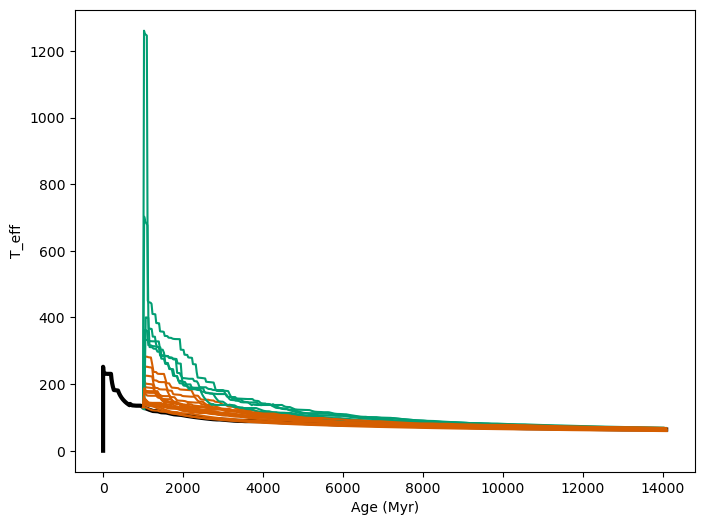

In [17]:
from scipy.interpolate import PchipInterpolator
fig, ax = plt.subplots(figsize = (8,6))
f_env = 0.2
refx, refy = track.get_obs_threshold_points(dfcontrols[f_env], impact_time=1000)
sns.lineplot(data=dfcontrols[f_env], x="Age", y="T_eff", ax=ax, color='black', label='Control', lw=3)
#sns.lineplot(x=refx, y=refy, ax=ax, linestyle="--", lw=1, color=palette[7])
i = 0
for key, df in evodfdicts[f_env].items():
    i += 1
    
    if i%2!=0:
        continue
    
    if key >= 0.0055:
        color=palette[2]
    if key < 0.0055:
        color=palette[3]
    
    try:
        df = df.dropna()
        obs_pchip = PchipInterpolator(x=df["Age"], y=df["T_eff"])
        modelAge = np.linspace(impact_time, max(df["Age"]), 400)
        obs_points = obs_pchip(modelAge)
        sns.lineplot(x=modelAge, y=obs_points, ax=ax, color=color, label=rf"{key}")
        #sns.scatterplot(data=df, x="Age", y="Radius", ax=ax, color=palette[7], alpha=0.5, s=10)
    except Exception as e:
        print(e.with_traceback(None))
        print(key)
        print(df)
        continue
ax.legend(fontsize='small', title=r"$M_{imp}/M_{core}$")
#axs[0].axhline(y=0.3, xmin=-1, xmax=15000, linestyle=":")
#ax.text(7000, 0.27, r"Super-puffs $<0.3gcm^{-3}$")
#ax.text(7500, 0.31, r"Typical $>0.3gcm^{-3}$")
#ax.set_ylabel(r"Radius ($M_{\oplus}$)")
ax.set_xlabel(r"Age (Myr)")
ax.get_legend().remove()
#ax.set_xlim(0,10000)
#ax.set_ylim(3,6)

In [18]:
evolveFileName = f"sim_results/impact-fenv01-evo-0-0052.dat"
df = track.load_track(evolveFileName).dropna()
obs_pchip = PchipInterpolator(x=df["Age"], y=df["Radius"])
modelAge = np.linspace(impact_time, max(df["Age"]), 400)
obs_points = obs_pchip(modelAge)
r_1GYR = obs_pchip(2000)

Using Pchip because: 
- Do not care about the underlying curve, it does not need to be parametric
- We are only using this for interpolating between points
- The data is only well fit by a piecewise function and it is non-continuous

Assure that Age column is monotonically increasing and then double check with np.diff
(accounting for the difference in scipy/np definitions, so ```diff != 0```)

In [19]:
timescales = {0.05:{}, 0.1:{}, 0.2:{}, 0.3:{}}
impact_corefracs = []
for f_env, data in evodfdicts.items():
    for key, df in data.items():
        print(f" {key} {f_env} ")
        try:
            tauObs = track.calc_observable_timescale(df.dropna(), dfcontrols[f_env], impact_time=impact_time)
            
        except IndexError as ie:
            print(f"IE {key}")
            tauObs = 0
        except ValueError as ve:
            print(ve.with_traceback(None))
            print(f"VE {key} {f_env}")
            print(df)
        if tauObs == 0:
            print(f"tauObs = 0 for {key} {f_env}")
            continue
        timescales[f_env][key] = tauObs
        if not key in impact_corefracs:
            impact_corefracs.append(key)


timescales[0.2]


 0.0012 0.1 
 0.001 0.1 
 0.0015 0.1 
 0.0017 0.1 
 0.0025 0.1 
 0.0022 0.1 
 0.002 0.1 
 0.0027 0.1 
 0.003 0.1 
 0.0032 0.1 
 0.0035 0.1 
 0.0037 0.1 
 0.004 0.1 
 0.0042 0.1 
 0.0045 0.1 
 0.0047 0.1 
 0.005 0.1 
 0.0052 0.1 
 0.001 0.2 
 0.0013 0.2 
 0.002 0.2 
 0.003 0.2 
 0.0016 0.2 
 0.0026 0.2 
 0.0023 0.2 
 0.0033 0.2 
 0.0036 0.2 
 0.004 0.2 
 0.0043 0.2 
 0.0046 0.2 
 0.005 0.2 
 0.0053 0.2 
 0.0056 0.2 
 0.006 0.2 
 0.0063 0.2 
 0.0066 0.2 
 0.007 0.2 
 0.0073 0.2 
 0.0076 0.2 
 0.008 0.2 
 0.0083 0.2 
 0.0086 0.2 
 0.009 0.2 
IE 0.009
tauObs = 0 for 0.009 0.2
 0.0012 0.2 
 0.0021 0.2 
 0.0014 0.2 
 0.0018 0.2 
 0.0025 0.2 
 0.0027 0.2 
 0.0001 0.2 
tauObs = 0 for 0.0001 0.2
 0.0007 0.2 
tauObs = 0 for 0.0007 0.2
 0.0009 0.2 
 0.0003 0.2 
tauObs = 0 for 0.0003 0.2
 0.0011 0.2 
 0.0005 0.2 
tauObs = 0 for 0.0005 0.2
 0.0022 0.2 
 0.0008 0.2 
tauObs = 0 for 0.0008 0.2
 0.0006 0.2 
tauObs = 0 for 0.0006 0.2
 0.0002 0.2 
tauObs = 0 for 0.0002 0.2
 0.0004 0.2 
tauObs = 0 for 0.0

{0.001: np.float64(65.16290726817033),
 0.0013: np.float64(553.8847117794485),
 0.002: np.float64(944.8621553884714),
 0.003: np.float64(2639.097744360902),
 0.0016: np.float64(619.047619047619),
 0.0026: np.float64(2606.5162907268173),
 0.0023: np.float64(2248.1203007518798),
 0.0033: np.float64(2736.842105263158),
 0.0036: np.float64(1531.3283208020048),
 0.004: np.float64(2671.6791979949876),
 0.0043: np.float64(2671.6791979949876),
 0.0046: np.float64(2476.190476190476),
 0.005: np.float64(4463.659147869675),
 0.0053: np.float64(3518.7969924812032),
 0.0056: np.float64(3551.378446115288),
 0.006: np.float64(3942.355889724311),
 0.0063: np.float64(2345.8646616541355),
 0.0066: np.float64(5538.847117794487),
 0.007: np.float64(4203.007518796992),
 0.0073: np.float64(5310.77694235589),
 0.0076: np.float64(4463.659147869675),
 0.008: np.float64(3812.0300751879695),
 0.0083: np.float64(5441.102756892231),
 0.0086: np.float64(5082.706766917294),
 0.0012: np.float64(390.97744360902243),
 

(0.0008, 0.0055)

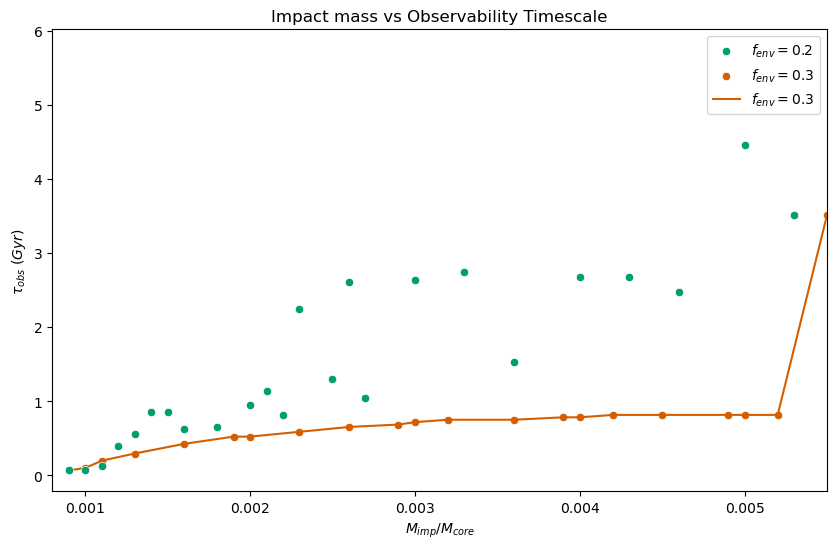

In [20]:
fig, ax = plt.subplots(figsize=(10,6))
#sns.scatterplot(x=timescales[0.1].keys(), y=timescales[0.1].values(), ax=ax, color=palette[1], label=r"$f_{env}=0.1$")
sns.scatterplot(x=timescales[0.2].keys(), y=timescales[0.2].values(), ax=ax, color=palette[2], label=r"$f_{env}=0.2$", zorder=4)
sns.scatterplot(x=timescales[0.3].keys(), y=timescales[0.3].values(), ax=ax, color=palette[3], label=r"$f_{env}=0.3$")
sns.lineplot(x=timescales[0.3].keys(), y=timescales[0.3].values(), ax=ax, color=palette[3], label=r"$f_{env}=0.3$")
#sns.lineplot(x=list(data.keys()), y=list(data.values()), ax = ax, lw=1, label=rf"${f_env}$")



ax.set_ylabel(r"$\tau_{obs}\ (Gyr)$")
ax.set_xlabel(r"$M_{imp}/M_{core}$")
ax.set_yticks([0, 1e3, 2e3, 3e3, 4e3, 5e3, 6e3])
ax.set_yticklabels([0, 1, 2, 3, 4, 5, 6])
ax.set_title(r"Impact mass vs Observability Timescale")
ax.set_xlim(0.0008, 0.0055)



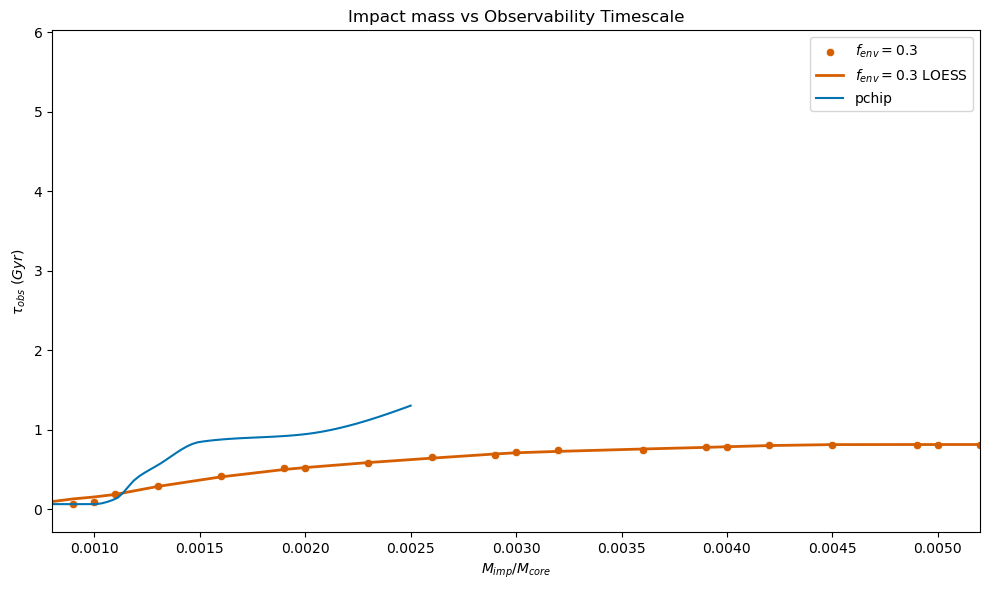

In [21]:
from statsmodels.nonparametric.smoothers_lowess import lowess
import numpy as np

fig, ax = plt.subplots(figsize=(10,6))

# Plot the scatter points for f_env=0.2
#sns.scatterplot(x=timescales[0.2].keys(), y=timescales[0.2].values(), ax=ax, color=palette[2], label=r"$f_{env}=0.2$", zorder=4)

# Plot the scatter points for f_env=0.3
sns.scatterplot(x=timescales[0.3].keys(), y=timescales[0.3].values(), 
                ax=ax, color=palette[3], label=r"$f_{env}=0.3$")

timescales[0.3][0.0005] = 0 #intercept
# LOESS fit for f_env=0.3

filtered_taus03 = {k: v for k, v in timescales[0.3].items() if k <= 0.0053}
imfs03 = np.array(list(filtered_taus03.keys()))
tauObs03 = np.array(list(filtered_taus03.values()))

# Sort by x values for proper plotting
sort_idx03 = np.argsort(imfs03)
x_sorted03 = imfs03[sort_idx03]
y_sorted03 = tauObs03[sort_idx03]

# Compute LOESS fit (frac controls smoothness: smaller = less smooth, larger = more smooth)
loess_result03 = lowess(y_sorted03, x_sorted03, frac=0.3)

# Plot LOESS curve
ax.plot(loess_result03[:, 0], loess_result03[:, 1], 
        color=palette[3], linewidth=2, label=r"$f_{env}=0.3$ LOESS")

#--------------------------0.2-------------------
timescales[0.2][0.0002] = 0 #intercept
# LOESS fit for f_env=0.3

good_imf = [0.0009, 0.001, 0.0011, 0.0012, 0.0013, 0.0015, 0.002, 0.0025]
filtered_taus02 = {k: v for k, v in timescales[0.2].items() if k in good_imf}
imfs02 = np.array(list(filtered_taus02.keys()))
tauObs02 = np.array(list(filtered_taus02.values()))
sort_idx02 = np.argsort(imfs02)
x_sorted02 = imfs02[sort_idx02]
y_sorted02 = tauObs02[sort_idx02]
tau_pchip = PchipInterpolator(x=x_sorted02, y=y_sorted02)
tau_x = np.linspace(0, 0.0025, 100)
obs_points = tau_pchip(tau_x)
sns.lineplot(x=tau_x, y=obs_points, ax=ax, label=rf"pchip")
ax.set_ylabel(r"$\tau_{obs}\ (Gyr)$")
ax.set_xlabel(r"$M_{imp}/M_{core}$")
ax.set_yticks([0, 1e3, 2e3, 3e3, 4e3, 5e3, 6e3])
ax.set_yticklabels([0, 1, 2, 3, 4, 5, 6])
ax.set_title(r"Impact mass vs Observability Timescale")
ax.set_xlim(0.0008, 0.0052)

plt.legend()
plt.tight_layout()

In [22]:
sorted_dict = dict(sorted(timescales[0.2].items()))
good_imf = [0.0009, 0.001, 0.0011, 0.0012, 0.0013, 0.0015, 0.002, 0.0025]
tauObs02 = {k: v for k, v in timescales[0.2].items() if k in good_imf}
sorted_dict

{0.0002: 0,
 0.0009: np.float64(65.16290726817033),
 0.001: np.float64(65.16290726817033),
 0.0011: np.float64(130.32581453634089),
 0.0012: np.float64(390.97744360902243),
 0.0013: np.float64(553.8847117794485),
 0.0014: np.float64(847.1177944862156),
 0.0015: np.float64(847.1177944862156),
 0.0016: np.float64(619.047619047619),
 0.0018: np.float64(651.6290726817042),
 0.002: np.float64(944.8621553884714),
 0.0021: np.float64(1140.3508771929828),
 0.0022: np.float64(814.5363408521303),
 0.0023: np.float64(2248.1203007518798),
 0.0025: np.float64(1303.2581453634084),
 0.0026: np.float64(2606.5162907268173),
 0.0027: np.float64(1042.6065162907269),
 0.003: np.float64(2639.097744360902),
 0.0033: np.float64(2736.842105263158),
 0.0036: np.float64(1531.3283208020048),
 0.004: np.float64(2671.6791979949876),
 0.0043: np.float64(2671.6791979949876),
 0.0046: np.float64(2476.190476190476),
 0.005: np.float64(4463.659147869675),
 0.0053: np.float64(3518.7969924812032),
 0.0056: np.float64(355